# Loopback Test

ADC - Analog to Digital Converter
DAC - Digital to Analog Converter
Board is Digital
 Send signal from DAC into ADC -- boards sends to itself

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Import Libraries</h2>
</div>

In [9]:
from qick import QickProgram, AveragerProgram
import qickdawg as qd
import matplotlib.pyplot as plt
import numpy as np
import inspect

In [2]:
#print(inspect.getsource(qd.start_client))

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Connect to Board</h2>
</div>

In [3]:
qd.start_client('10.225.208.77')
soc = qd.soc

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Class</h2>
</div>

In [4]:
class LoopbackTest(AveragerProgram):
    def initialize(self):
        cfg = self.cfg
        self.declare_gen(ch=cfg["gen_ch"], nqz=1)
        self.declare_readout(ch=cfg["ro_ch"], length=cfg["readout_length"], freq=cfg["pulse_freq"], gen_ch=cfg["gen_ch"])
        self.set_pulse_registers(ch=cfg["gen_ch"], style="const", freq=cfg["pulse_freq"],
                                  phase=0, gain=cfg["gain"], length=cfg["pulse_length"])
        self.synci(200)

    def body(self):
        self.trigger(adcs=[self.cfg["ro_ch"]], adc_trig_offset=self.cfg["trig_offset"])
        self.pulse(ch=self.cfg["gen_ch"])
        self.wait_all()
        self.sync_all(self.cfg["relax_delay"])

In [48]:
print(len(iq_shifted[0][0]))
print(config["readout_length"])

200
200


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Configurations</h2>
</div>

In [21]:
print("pulse length (us):", soccfg.cycles2us(config["pulse_length"], gen_ch=config["gen_ch"]))
print("readout length (us):", soccfg.cycles2us(config["readout_length"], ro_ch=config["ro_ch"]))
print("trig offset (us):", soccfg.cycles2us(config["trig_offset"], ro_ch=config["ro_ch"]))

pulse length (us): 0.32552083333333337
readout length (us): 0.6510416666666667
trig offset (us): 0.16276041666666669


In [57]:
config = {
    "gen_ch": 0, #signal generator - DAC
    "ro_ch": 1, #readout channel - ADC  
    "pulse_freq": 100,       # MHz
    "gain": 5000,
    "pulse_length": 200,     # cycles
    "readout_length": 200,   # cycles
    "trig_offset": 50, #delay between triggering adc and adc actually start listening
    "reps": 100, #fire pulse --> listen --> relax_delay x100
    "relax_delay": 1.0,      # us
}

<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Run</h2>
</div>

In [32]:
#signal trigger and readout trigger are called back to back -- same instant
soccfg = qd.soccfg
prog = LoopbackTest(soccfg, config)
iq_list = prog.acquire(soc, load_pulses=True, progress=True)

100%|██████████| 100/100 [00:00<00:00, 21494.92it/s]


<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Plot</h2>
</div>

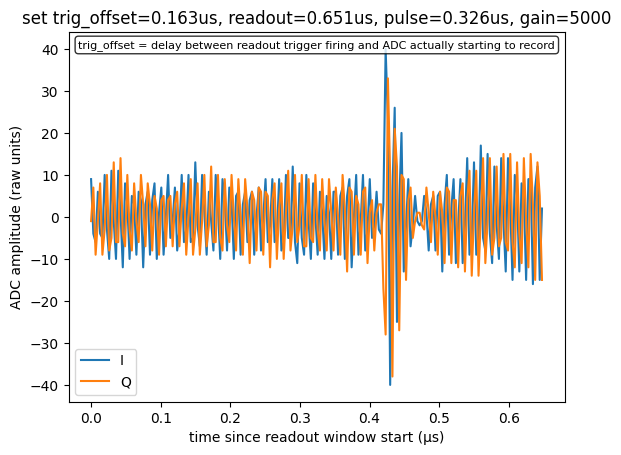

In [39]:
pulse_len_us = soccfg.cycles2us(config["pulse_length"], gen_ch=config["gen_ch"])
readout_len_us = soccfg.cycles2us(config["readout_length"], ro_ch=config["ro_ch"])
trig_offset_us = soccfg.cycles2us(config["trig_offset"], ro_ch=config["ro_ch"])

plt.plot(t_us, iq_real[0][0], label="I")
plt.plot(t_us, iq_real[0][1], label="Q")
plt.xlabel("time since readout window start (µs)")
plt.ylabel("ADC amplitude (raw units)")
plt.text(0.02, 0.98,
         "trig_offset = delay between readout trigger firing and ADC actually starting to record",
         transform=plt.gca().transAxes, fontsize=8, va='top', ha='left',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.title(f"set trig_offset={trig_offset_us:.3f}us, readout={readout_len_us:.3f}us, "
          f"pulse={pulse_len_us:.3f}us, gain={config['gain']}")
plt.legend()
plt.show()

100%|██████████| 1/1 [00:00<00:00, 23.77it/s]


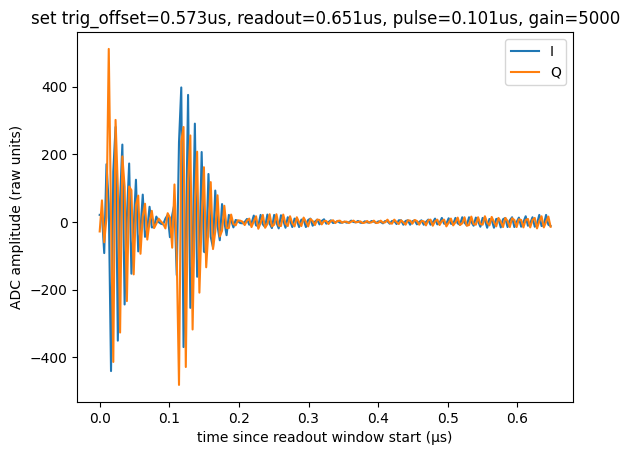

In [87]:
pulse_len_cycles = soccfg.us2cycles(0.1, gen_ch=config["gen_ch"])  # <-- set desired pulse length in us here

readout_len_us = soccfg.cycles2us(config["readout_length"], ro_ch=config["ro_ch"])
extra_offset_us = 0.41
extra_cycles = soccfg.us2cycles(extra_offset_us, ro_ch=config["ro_ch"])

config_shifted = dict(config_decimated)
config_shifted["trig_offset"] = config["trig_offset"] + extra_cycles
config_shifted["pulse_length"] = pulse_len_cycles

prog = LoopbackTest(soccfg, config_shifted)
iq_shifted = prog.acquire_decimated(soc, load_pulses=True, progress=True)

trig_offset_shifted_us = soccfg.cycles2us(config_shifted["trig_offset"], ro_ch=config["ro_ch"])
pulse_len_us = soccfg.cycles2us(config_shifted["pulse_length"], gen_ch=config["gen_ch"])

plt.plot(t_us, iq_shifted[0][0], label="I")
plt.plot(t_us, iq_shifted[0][1], label="Q")
plt.xlabel("time since readout window start (µs)")
plt.ylabel("ADC amplitude (raw units)")
plt.title(f"set trig_offset={trig_offset_shifted_us:.3f}us, readout={readout_len_us:.3f}us, "
          f"pulse={pulse_len_us:.3f}us, gain={config['gain']}")
plt.legend()
plt.show()

100%|██████████| 1/1 [00:00<00:00, 88.09it/s]


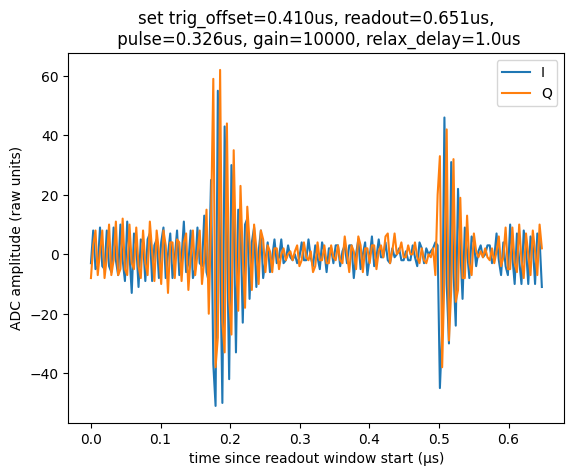

In [93]:
# ---- knobs ----
GAIN = 10000
TRIG_OFFSET_US = 0.41
PULSE_LENGTH_US = 0.326
RELAX_DELAY_US = 1.0
READOUT_LENGTH_CYCLES = config["readout_length"]  # unchanged from original config
REPS = 1
# ----------------

config_clean = dict(config_decimated)
config_clean["gain"] = GAIN
config_clean["trig_offset"] = soccfg.us2cycles(TRIG_OFFSET_US, ro_ch=config["ro_ch"])
config_clean["pulse_length"] = soccfg.us2cycles(PULSE_LENGTH_US, gen_ch=config["gen_ch"])
config_clean["relax_delay"] = RELAX_DELAY_US
config_clean["readout_length"] = READOUT_LENGTH_CYCLES
config_clean["reps"] = REPS

prog = LoopbackTest(soccfg, config_clean)
iq_clean = prog.acquire_decimated(soc, load_pulses=True, progress=True)

pulse_len_us = soccfg.cycles2us(config_clean["pulse_length"], gen_ch=config["gen_ch"])
readout_len_us = soccfg.cycles2us(config_clean["readout_length"], ro_ch=config["ro_ch"])
trig_offset_us = soccfg.cycles2us(config_clean["trig_offset"], ro_ch=config["ro_ch"])

plt.plot(t_us, iq_clean[0][0], label="I")
plt.plot(t_us, iq_clean[0][1], label="Q")
plt.xlabel("time since readout window start (µs)")
plt.ylabel("ADC amplitude (raw units)")
plt.title(f"set trig_offset={trig_offset_us:.3f}us, readout={readout_len_us:.3f}us,\n "
          f"pulse={pulse_len_us:.3f}us, gain={config_clean['gain']}, "
          f"relax_delay={config_clean['relax_delay']}us")
plt.legend()
plt.show()

100%|██████████| 1/1 [00:00<00:00, 83.23it/s]


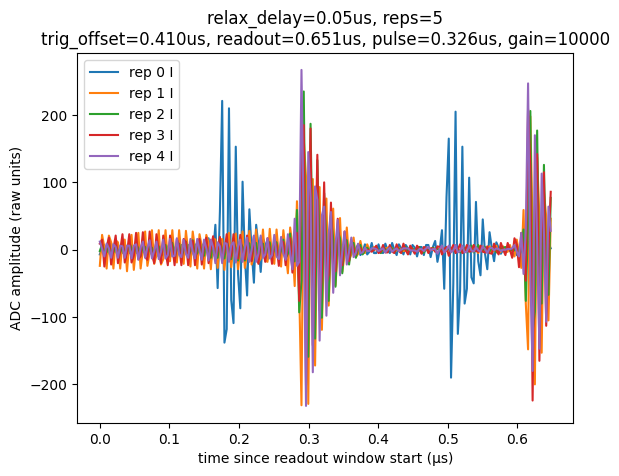

In [169]:
# ---- knobs ----
GAIN = 10000
TRIG_OFFSET_US = 0.41
PULSE_LENGTH_US = 0.326
RELAX_DELAY_US = 0.05
READOUT_LENGTH_CYCLES = config["readout_length"]  # unchanged from original config
REPS = 5
# ----------------

config_clean = dict(config_decimated)
config_clean["gain"] = GAIN
config_clean["trig_offset"] = soccfg.us2cycles(TRIG_OFFSET_US, ro_ch=config["ro_ch"])
config_clean["pulse_length"] = soccfg.us2cycles(PULSE_LENGTH_US, gen_ch=config["gen_ch"])
config_clean["relax_delay"] = RELAX_DELAY_US
config_clean["readout_length"] = READOUT_LENGTH_CYCLES
config_clean["reps"] = REPS

prog = LoopbackTest(soccfg, config_clean)
iq_clean = prog.acquire_decimated(soc, load_pulses=True, progress=True)

pulse_len_us = soccfg.cycles2us(config_clean["pulse_length"], gen_ch=config["gen_ch"])
readout_len_us = soccfg.cycles2us(config_clean["readout_length"], ro_ch=config["ro_ch"])
trig_offset_us = soccfg.cycles2us(config_clean["trig_offset"], ro_ch=config["ro_ch"])

if config_clean["reps"] == 1:
    plt.plot(t_us, iq_clean[0][0], label="rep 0 I")
else:
    for r in range(config_clean["reps"]):
        plt.plot(t_us, iq_clean[0][r][0], label=f"rep {r} I")

plt.xlabel("time since readout window start (µs)")
plt.ylabel("ADC amplitude (raw units)")
plt.title(f"relax_delay={config_clean['relax_delay']}us, reps={config_clean['reps']}\n"
          f"trig_offset={trig_offset_us:.3f}us, readout={readout_len_us:.3f}us, "
          f"pulse={pulse_len_us:.3f}us, gain={config_clean['gain']}")
plt.legend()
plt.show()

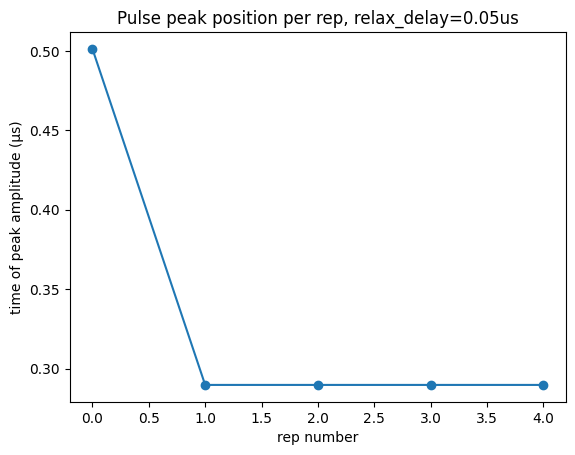

In [170]:
import numpy as np

peak_positions = []
for r in range(config_clean["reps"]):
    amp = np.sqrt(iq_clean[0][r][0]**2 + iq_clean[0][r][1]**2)
    peak_idx = np.argmax(amp)
    peak_positions.append(t_us[peak_idx])

plt.plot(peak_positions, marker='o')
plt.xlabel("rep number")
plt.ylabel("time of peak amplitude (µs)")
plt.title(f"Pulse peak position per rep, relax_delay={config_clean['relax_delay']}us")
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:00<00:00, 72.27it/s] 


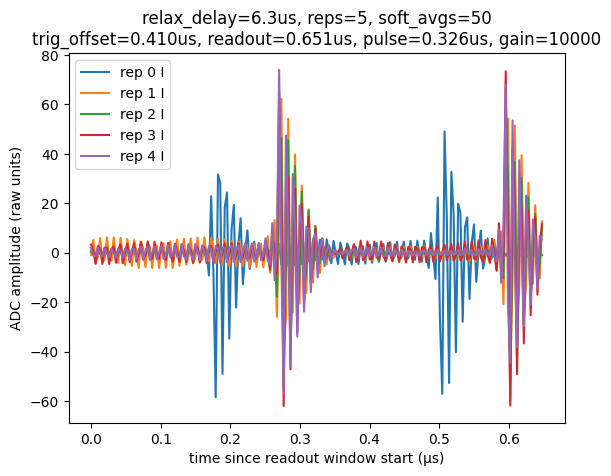

In [161]:
# ---- knobs ----
GAIN = 10000
TRIG_OFFSET_US = 0.41
PULSE_LENGTH_US = 0.326
RELAX_DELAY_US = 6.3
READOUT_LENGTH_CYCLES = config["readout_length"]
REPS = 5
SOFT_AVGS = 50
# ----------------

config_clean = dict(config_decimated)
config_clean["gain"] = GAIN
config_clean["trig_offset"] = soccfg.us2cycles(TRIG_OFFSET_US, ro_ch=config["ro_ch"])
config_clean["pulse_length"] = soccfg.us2cycles(PULSE_LENGTH_US, gen_ch=config["gen_ch"])
config_clean["relax_delay"] = RELAX_DELAY_US
config_clean["readout_length"] = READOUT_LENGTH_CYCLES
config_clean["reps"] = REPS

prog = LoopbackTest(soccfg, config_clean)
prog.soft_avgs = SOFT_AVGS
iq_clean = prog.acquire_decimated(soc, load_pulses=True, progress=True)

pulse_len_us = soccfg.cycles2us(config_clean["pulse_length"], gen_ch=config["gen_ch"])
readout_len_us = soccfg.cycles2us(config_clean["readout_length"], ro_ch=config["ro_ch"])
trig_offset_us = soccfg.cycles2us(config_clean["trig_offset"], ro_ch=config["ro_ch"])

if config_clean["reps"] == 1:
    plt.plot(t_us, iq_clean[0][0], label="rep 0 I")
else:
    for r in range(config_clean["reps"]):
        plt.plot(t_us, iq_clean[0][r][0], label=f"rep {r} I")

plt.xlabel("time since readout window start (µs)")
plt.ylabel("ADC amplitude (raw units)")
plt.title(f"relax_delay={config_clean['relax_delay']}us, reps={config_clean['reps']}, soft_avgs={SOFT_AVGS}\n"
          f"trig_offset={trig_offset_us:.3f}us, readout={readout_len_us:.3f}us, "
          f"pulse={pulse_len_us:.3f}us, gain={config_clean['gain']}")
plt.legend()
plt.show()

100%|██████████| 20/20 [00:00<00:00, 32.72it/s]


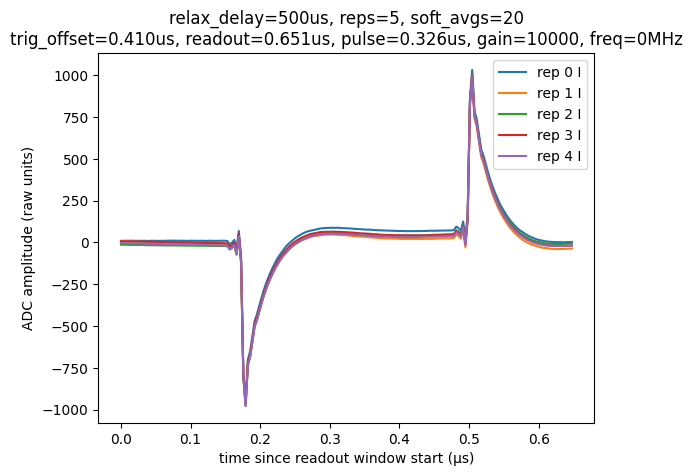

In [160]:
# ---- knobs ----
GAIN = 10000
TRIG_OFFSET_US = 0.41
PULSE_LENGTH_US = 0.326
PULSE_FREQ_MHZ = 0        # 0 = flat/DC pulse, no oscillation
RELAX_DELAY_US = 500
READOUT_LENGTH_CYCLES = config["readout_length"]
REPS = 5
SOFT_AVGS = 20
# ----------------

config_clean = dict(config_decimated)
config_clean["gain"] = GAIN
config_clean["trig_offset"] = soccfg.us2cycles(TRIG_OFFSET_US, ro_ch=config["ro_ch"])
config_clean["pulse_length"] = soccfg.us2cycles(PULSE_LENGTH_US, gen_ch=config["gen_ch"])
config_clean["pulse_freq"] = PULSE_FREQ_MHZ
config_clean["relax_delay"] = RELAX_DELAY_US
config_clean["readout_length"] = READOUT_LENGTH_CYCLES
config_clean["reps"] = REPS

prog = LoopbackTest(soccfg, config_clean)
prog.soft_avgs = SOFT_AVGS
iq_clean = prog.acquire_decimated(soc, load_pulses=True, progress=True)

pulse_len_us = soccfg.cycles2us(config_clean["pulse_length"], gen_ch=config["gen_ch"])
readout_len_us = soccfg.cycles2us(config_clean["readout_length"], ro_ch=config["ro_ch"])
trig_offset_us = soccfg.cycles2us(config_clean["trig_offset"], ro_ch=config["ro_ch"])

if config_clean["reps"] == 1:
    plt.plot(t_us, iq_clean[0][0], label="rep 0 I")
else:
    for r in range(config_clean["reps"]):
        plt.plot(t_us, iq_clean[0][r][0], label=f"rep {r} I")

plt.xlabel("time since readout window start (µs)")
plt.ylabel("ADC amplitude (raw units)")
plt.title(f"relax_delay={config_clean['relax_delay']}us, reps={config_clean['reps']}, soft_avgs={SOFT_AVGS}\n"
          f"trig_offset={trig_offset_us:.3f}us, readout={readout_len_us:.3f}us, "
          f"pulse={pulse_len_us:.3f}us, gain={config_clean['gain']}, freq={PULSE_FREQ_MHZ}MHz")
plt.legend()
plt.show()